### Imports, Loading Model & Defining Optimization

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.spatial.distance import cdist

import torch
import torch.nn as nn
import sk2torch

from sklearn.preprocessing import PolynomialFeatures

from itertools import combinations, combinations_with_replacement
import re
import os
import joblib
import pickle

In [4]:
# Polynomial Model
with open("BestModels/WithoutOutliers/RidgeRegression.pkl", "rb") as model:
    lin_model=joblib.load(model)
with open("Data/Transformed_OutlierAdjusted/xNormalizer.pkl", "rb") as norm:
    xNormalizer=joblib.load(norm)
with open("Data/Transformed_OutlierAdjusted/yScaler.pkl", "rb") as norm:
    yScaler=joblib.load(norm)
    
#Data:
X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None
with open("Data/Transformed_OutlierAdjusted/split.pkl", "rb") as file:
    data_dict = pickle.load(file)
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_val = data_dict["X_val"]
    y_val = data_dict["y_val"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]
X_data=pd.concat([X_train, X_val, X_test])
X_data.reset_index(drop=True, inplace=True)
y_data=pd.concat([y_train, y_val, y_test])
y_data.reset_index(drop=True, inplace=True)
Xcolumns = X_train.columns
ycolumns = y_train.columns

data_tensor = torch.tensor(X_data.values, dtype=torch.float64)

/home/ehanser/CALETana/MLProject/.venv/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PolynomialFeatures from version 1.3.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.3.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from ver

### Average Distance Between Data Points

Average nearest neighbor distance: 0.0281943345029808 for 4960 points: in 17 dimensions


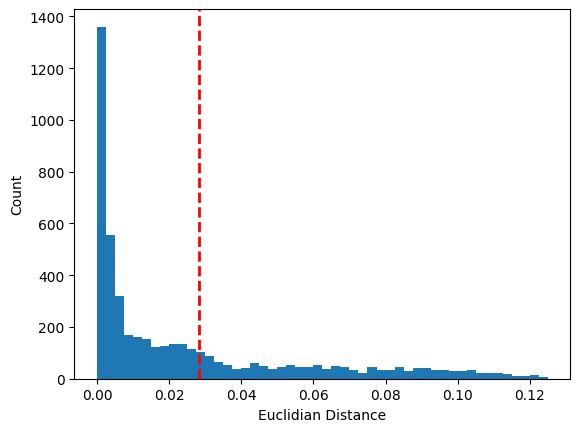

In [5]:
def average_nearest_neighbor_distance(points):
    # Create a KDTree for efficient nearest neighbor search
    kdtree = KDTree(points)
    # Query the KDTree to find the distance to the nearest neighbor for each point
    distances, _ = kdtree.query(points, k=2)
    # The nearest neighbor distance is at index 1 (index 0 is the point itself)
    nearest_distances = distances[:, 1]
    # Calculate the average of the nearest neighbor distances
    average_distance = np.mean(nearest_distances)
    plt.hist(nearest_distances, bins=50, range=(0,0.125), label="NN Distances")
    plt.axvline(average_distance, color = "red", linestyle = "dashed",linewidth =2, label="Average NN Distance")
    plt.xlabel("Euclidian Distance")
    plt.ylabel("Count")
    print(f"Average nearest neighbor distance: {average_distance} for {len(points)} points: in {len(points.columns)} dimensions")
    return average_distance

# Calculate the average nearest neighbor distance
avg_distance = average_nearest_neighbor_distance(X_data)


### Best results so far

Average nearest neighbor distance: 0.012094555068881066 for 50 points: in 17 dimensions


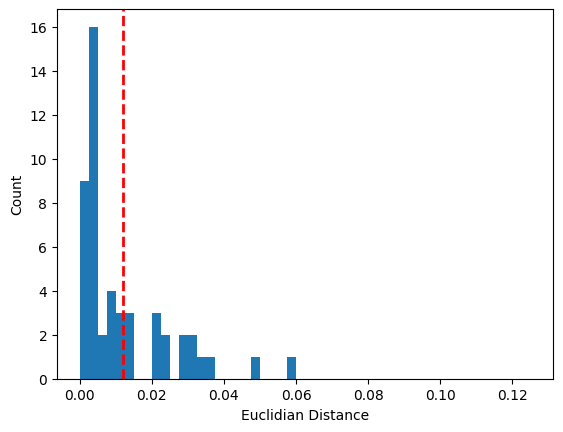

In [7]:
def loss_pd(y):
    y = np.exp(y)   
    y = np.sum(y)
    return y  

y_der = y_data.copy()
y_der["metric"] = y_data.apply(loss_pd, axis=1)
top_indices = y_der.sort_values(by="metric", ascending=True).head(50).index.tolist()
top_X = X_data.loc[top_indices]
top_y = y_der.loc[top_indices]
_ = average_nearest_neighbor_distance(top_X)

### Gradient Descent

##### Hyperparams

In [20]:
# Hyperparams
num_steps = 25
learning_rate = 0.01

# Fixed params
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
degree = lin_model[0].degree

##### Model Setup

In [21]:
def polynomial(t: torch.Tensor, degree: int =2, interaction_only: bool = False) -> torch.Tensor:
    cols = t.hsplit(t.shape[1])
    if interaction_only:
        degree = 2
        combs = combinations(cols, degree)
    else:
        combs = combinations_with_replacement(cols, degree)
    prods = [torch.prod(torch.hstack(comb), -1).unsqueeze(-1) for comb in combs]
    r = torch.hstack(prods)
    return torch.hstack((t,r)) if degree == 2 else torch.hstack((polynomial(t, degree -1), r))

class RidgeModel(nn.Module):
    def __init__(self, coefficients, intercepts):
        super(RidgeModel, self).__init__()
        self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
        self.intercepts = torch.tensor(intercepts, dtype=torch.float64)
    
    def forward(self, x_poly):
        return x_poly @ self.coefficients.T + self.intercepts
    
# Function to optimize:
def loss(y):
    # Polynomial regression output mimics originally standard normal distributed N(0,1) target 
    # don't rescale output to original for optimization, but apply exp again
    y = torch.exp(y)   
    y = torch.sum(y)
    return y   

def distance_penalty(new_point, orig_data):
    distances = torch.norm(orig_data-new_point, dim=1)
    min_distance = torch.min(distances)
    penalty=0
    if(min_distance > avg_distance): 
        penalty = (min_distance-avg_distance)*torch.exp(min_distance-avg_distance)*100
        # penalty = min_distance*torch.exp(min_distance)*100
    return penalty

# Create model and push it to run on the device  
coefficients = lin_model[1].coef_
intercepts = lin_model[1].intercept_
rmodel = RidgeModel(coefficients, intercepts).to(device)

##### Optimization

In [23]:
def optimize(par, optimizer):
    val_losses = []
    for steps in range(num_steps):        
        #Forward pass
        y = polynomial(par, 4)
        y = rmodel(y)
        l = loss(y)+distance_penalty(par, data_tensor)
        # l = loss(y)
        #Backward pass
        l.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        val_losses.append(l)
        # if (steps)%10==0: print("Epoch:", steps, "Current Loss:", l)  
    print(f"Loss improvement: {(val_losses[-1]-val_losses[0])/val_losses[0]*100:.3}%, Final parameters:\n", par)
    return par, val_losses[-1]

result_df = pd.DataFrame(columns=Xcolumns)
scorelist = []
for index, row in top_X.iterrows():
    row_tensor = torch.tensor([row], requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.Adam([row_tensor], lr=learning_rate)
    result, score = optimize(row_tensor, optimizer)
    new_row = pd.DataFrame(result.detach().numpy(), columns=Xcolumns)
    scorelist.append(score.detach().numpy())
    result_df = pd.concat([result_df, new_row], ignore_index=True)

Loss improvement: -40.6%, Final parameters:
 tensor([[0.8180, 0.5200, 0.5070, 0.8580, 0.1749, 0.2178, 0.2359, 0.8771, 0.8532,
         0.5479, 0.8270, 0.0028, 0.1649, 0.6811, 0.7380, 0.5307, 0.0656]],
       dtype=torch.float64, requires_grad=True)
Loss improvement: -31.4%, Final parameters:
 tensor([[0.8221, 0.5079, 0.5023, 0.8589, 0.1775, 0.2232, 0.2335, 0.8802, 0.8614,
         0.5499, 0.8272, 0.0014, 0.1655, 0.6787, 0.7350, 0.5307, 0.0656]],
       dtype=torch.float64, requires_grad=True)
Loss improvement: -21.0%, Final parameters:
 tensor([[0.8241, 0.5107, 0.5028, 0.8595, 0.1775, 0.2247, 0.2333, 0.8793, 0.8598,
         0.5479, 0.8300, 0.0027, 0.1598, 0.6791, 0.7354, 0.5310, 0.0655]],
       dtype=torch.float64, requires_grad=True)
Loss improvement: -29.4%, Final parameters:
 tensor([[0.8157, 0.4813, 0.5175, 0.8785, 0.1644, 0.2236, 0.2346, 0.9008, 0.8906,
         0.5651, 0.8075, 0.0126, 0.1599, 0.6609, 0.7525, 0.5156, 0.0709]],
       dtype=torch.float64, requires_grad=True)
Loss

In [32]:
# Obtain to be simulated parameters
lowest_indices = np.argsort(scorelist)[:10]
simulation_trials = result_df.iloc[lowest_indices]
trial_parameters = pd.DataFrame(xNormalizer.inverse_transform(simulation_trials), columns=Xcolumns)
trial_parameters

# 12.107242021978083
# 12.386426188273129
# 12.295020745777427
# 12.050348828864001
# 13.013456273865637
# 13.047587357958063
# 13.006102461633542
# 12.528146791740049
# 12.444777031707837
# 12.351611135562253


,sindex,nuccut,diffexp,lowindx,lowexp,lowdiffbreak,lowdiffbreaksoft,diffnorm,DE,DR,alvel,highexp,diffbreak,diffbreaksoft,lowbreak,lowsoft,spiralwidth
0,2.914817,31.544507,0.514420,2.104112,0.136165,11.290063,0.084838,3.806091,6.121379,8.498445,17.132816,0.002720,534.132574,0.366998,25.078467,0.174782,0.150593
1,2.917318,30.703466,0.512285,2.107975,0.132472,11.403670,0.088593,3.862489,6.259611,8.312171,17.210503,0.003013,512.144331,0.364557,25.779241,0.175186,0.120146
2,2.916493,30.894393,0.512658,2.105249,0.134297,11.466006,0.088263,3.843505,6.187991,8.410608,17.227199,0.003215,521.575589,0.364297,25.587368,0.178233,0.120424
3,2.914559,30.838070,0.515924,2.103621,0.135895,11.427124,0.086089,3.806980,6.145232,8.534127,17.127489,0.003180,534.037310,0.363938,25.275828,0.177184,0.142633
4,2.912046,32.373820,0.508842,2.099177,0.137198,11.215352,0.089021,3.803204,6.084388,8.501888,17.122467,0.002335,560.893358,0.361657,24.484564,0.186045,0.155541
5,2.912044,32.371540,0.508823,2.099191,0.137232,11.218425,0.089008,3.803327,6.084648,8.501712,17.122840,0.002351,560.942140,0.361574,24.477948,0.186059,0.155413
6,2.912024,32.352007,0.508898,2.099152,0.137187,11.216204,0.088960,3.802213,6.081602,8.496509,17.124804,0.002315,560.821301,0.361490,24.481145,0.186105,0.155585
7,2.919622,33.085366,0.505614,2.102627,0.134008,11.568234,0.092261,3.765949,6.098948,8.017486,17.789028,0.000537,503.859829,0.375576,25.808665,0.185661,0.060498
8,2.911654,31.565848,0.512651,2.099466,0.137485,11.187187,0.086401,3.807351,6.112591,8.532270,17.059728,0.002455,553.177699,0.362911,24.707719,0.181139,0.162958
9,2.911529,31.584837,0.512618,2.099512,0.137426,11.202655,0.086366,3.802847,6.098226,8.523115,17.068812,0.002350,553.187974,0.363257,24.672573,0.181106,0.163099


In [44]:
param_dict={"indxscan":"sindex","ncut":"nuccut","deltscan":"diffexp","lowindex":"lowindx","lowdelt":"lowexp","lowdeltbreak":"lowdiffbreak",
            "lowdbreaksoft":"lowdiffbreaksoft","Dscan":"diffnorm", "diffscaleheight":"DE","diffscaleradius":"DR","reaccscan":"alvel",
            "highdelt":"highexp","deltbreak":"diffbreak","dbreaksoft":"diffbreaksoft","lowbreak":"lowbreak","lowsoft":"lowsoft","SW":"spiralwidth"}
for i, row in trial_parameters.iterrows():
    print(f"------------{i+1}------------")
    for key, value in param_dict.items():
        if key in ["deltscan","Dscan","reaccscan","indxscan"]: print(f"{key}=[{row[value]:.4f}]")
        else: print(f"{key}={row[value]:.4f}")
    print("\n")


------------1------------
indxscan=[2.9148]
ncut=31.5445
deltscan=[0.5144]
lowindex=2.1041
lowdelt=0.1362
lowdeltbreak=11.2901
lowdbreaksoft=0.0848
Dscan=[3.8061]
diffscaleheight=6.1214
diffscaleradius=8.4984
reaccscan=[17.1328]
highdelt=0.0027
deltbreak=534.1326
dbreaksoft=0.3670
lowbreak=25.0785
lowsoft=0.1748
SW=0.1506


------------2------------
indxscan=[2.9173]
ncut=30.7035
deltscan=[0.5123]
lowindex=2.1080
lowdelt=0.1325
lowdeltbreak=11.4037
lowdbreaksoft=0.0886
Dscan=[3.8625]
diffscaleheight=6.2596
diffscaleradius=8.3122
reaccscan=[17.2105]
highdelt=0.0030
deltbreak=512.1443
dbreaksoft=0.3646
lowbreak=25.7792
lowsoft=0.1752
SW=0.1201


------------3------------
indxscan=[2.9165]
ncut=30.8944
deltscan=[0.5127]
lowindex=2.1052
lowdelt=0.1343
lowdeltbreak=11.4660
lowdbreaksoft=0.0883
Dscan=[3.8435]
diffscaleheight=6.1880
diffscaleradius=8.4106
reaccscan=[17.2272]
highdelt=0.0032
deltbreak=521.5756
dbreaksoft=0.3643
lowbreak=25.5874
lowsoft=0.1782
SW=0.1204


------------4---------

In [1]:
# def best_perf_index(pred, metric):
#     min_score = float("inf")
#     min_index = None
#     for i, row in pred.iterrows():
#         score = metric(torch.tensor(row))
#         if score<min_score:
#             min_score = score
#             min_index = i
#     print(min_score)
#     return min_index

# def closest_neighbor_distance(new_point, points):
#     distances = cdist([new_point], points)
#     return np.min(distances)
# new_point = par.detach().numpy()[0]
# distance = closest_neighbor_distance(new_point, X_data)
# print("Distance to closest neighbor:", distance)

In [ ]:
# distance = closest_neighbor_distance([0.,0.,0.,1.,0.,0.,1.,0.,1.,0.,0.,1.,0.,1.,1.,1.,1.], X_data)
# # distance = closest_neighbor_distance([1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.,1.], X_data)
# print("Distance to closest neighbor:", distance)

In [146]:
# Current best performance: 1.9118
# Avg neighbor dist: 0.0281943345029808
# Highest dist in hypercube: ~2.3

# --loss------------------nnDistance-----------performance
# None:                0.994363355439725400----0.0007
# (d-avg)*exp(d-avg):  0.025636845096791566----1.5046
# d*exp(d):            0.030520838461734420----1.5586